In [1]:
# ============================================================================
# RECTIFIED per_simmons.ipynb - Pat Simmons Channel Analysis
# ============================================================================

# Cell 1: Configuration
channel_name = 'Pat Simmons'

In [3]:
# Cell 2: Imports and API Setup
import pandas as pd
from datetime import datetime, timedelta
from googleapiclient.discovery import build
import os
import re
import seaborn as sns
import matplotlib.pyplot as plt
from dotenv import load_dotenv

load_dotenv()
YOUTUBE_DEVELOPER_KEY = os.getenv('YOUTUBE_DEVELOPER_KEY')

if not YOUTUBE_DEVELOPER_KEY:
    raise ValueError("YouTube API key not found. Please create a .env file with YOUTUBE_API_KEY=")

youtube = build('youtube', 'v3', developerKey=YOUTUBE_DEVELOPER_KEY)

In [5]:
# Cell 3: Quota Management
def get_quota_reset_info():
    """Get information about when quota resets and suggest action"""
    import pytz
    pacific = pytz.timezone('America/Los_Angeles')
    now_pt = datetime.now(pacific)
    
    reset_time = now_pt.replace(hour=0, minute=0, second=0, microsecond=0)
    if now_pt >= reset_time:
        reset_time += timedelta(days=1)
    
    time_until_reset = reset_time - now_pt
    hours_until_reset = time_until_reset.total_seconds() / 3600
    
    print(f"Current PT time: {now_pt.strftime('%H:%M')}")
    print(f"Quota resets in: {hours_until_reset:.1f} hours")
    
    if hours_until_reset < 4:
        print("⚠️  Caution: Limited time until quota reset")
        if hours_until_reset < 1:
            print("✅ Consider waiting for fresh quota")
    
    return hours_until_reset

get_quota_reset_info()

Current PT time: 02:13
Quota resets in: 21.8 hours


21.77839314777778

### Must input channel name manually

In [10]:
# Cell 4: Find the correct channel (Pat Simmons)
def search_channels(youtube, query, max_results=10):
    """Search for channels matching the query"""
    search_response = youtube.search().list(
        q=query,
        type='channel',
        part='id,snippet',
        maxResults=max_results
    ).execute()
    return search_response['items']

def get_channel_stats_by_id(youtube, channel_id):
    """Get channel statistics by ID"""
    request = youtube.channels().list(
        part="snippet,contentDetails,statistics",
        id=channel_id
    )
    return request.execute()['items'][0]

# Search for the channel
items = search_channels(youtube, "Pat Simmons", max_results=10)
print(f"Found {len(items)} channels matching 'Pat Simmons':\n")

for i, item in enumerate(items):
    channel_id = item['id']['channelId']
    channel_title = item['snippet']['title']
    description = item['snippet']['description'][:100] if item['snippet']['description'] else 'No description'
    
    stats = get_channel_stats_by_id(youtube, channel_id)['statistics']
    subs = stats.get('subscriberCount', 'Hidden')
    videos = stats.get('videoCount', 'Unknown')
    
    print(f"{i+1}. Channel: {channel_title}")
    print(f"   ID: {channel_id}")
    print(f"   Subscribers: {subs}")
    print(f"   Videos: {videos}")
    print(f"   Description: {description[:100]}\n")

Found 10 channels matching 'Pat Simmons':

1. Channel: Pat Simmons
   ID: UCY8ZKVxXj0FgIvSfeiSDclg
   Subscribers: 20000
   Videos: 69
   Description: On this channel you'll find non-technical AI tools and workflows that will help you save hours, do b

2. Channel: Patrick Simmons - Topic
   ID: UCaQIdypYgauLag0L32F3lkg
   Subscribers: 389
   Videos: 75
   Description: No description

3. Channel: Pat Simmons - Topic
   ID: UCSjI_rwTPBcB5Bb-ifeOIQw
   Subscribers: 3
   Videos: 15
   Description: No description

4. Channel: The Doobie Brothers - Topic
   ID: UCu_glVzsM9pvbSyXi2zzuVA
   Subscribers: 4310
   Videos: 1980
   Description: No description

5. Channel: Pat Simmons Jr.
   ID: UCxkO8WwpfnYga4S0vgMwvFQ
   Subscribers: 138
   Videos: 17
   Description: No description

6. Channel: Pat Simmons UK
   ID: UCQpSXq1KSF-qAO06qEmWAPQ
   Subscribers: 6
   Videos: 27
   Description: No description

7. Channel: Patrick Boyle
   ID: UCASM0cgfkJxQ1ICmRilfHLw
   Subscribers: 1280000
   Videos: 47

### Must input channel id from abouve step

In [13]:
# Cell 5: Set the correct channel ID for Pat Simmons
# Based on search results, Pat Simmons' channel ID is UCY8ZKVxXj0FgIvSfeiSDclg
PAT_SIMMONS_CHANNEL_ID = 'UCY8ZKVxXj0FgIvSfeiSDclg'
channel_id = PAT_SIMMONS_CHANNEL_ID

print(f"✅ Using channel: Pat Simmons")
print(f"Channel ID: {channel_id}")

# Verify the channel
channel_info = get_channel_stats_by_id(youtube, channel_id)
print(f"Channel Title: {channel_info['snippet']['title']}")
print(f"Description: {channel_info['snippet']['description'][:150]}...")

✅ Using channel: Pat Simmons
Channel ID: UCY8ZKVxXj0FgIvSfeiSDclg
Channel Title: Pat Simmons
Description: On this channel you’ll find non-technical AI tools and workflows that will help you save hours, do better work, and become the AI go-to person on your...


In [15]:
# Cell 6: Get Channel Stats
def get_channel_stats(youtube, channel_id):
    request = youtube.channels().list(
        part="snippet,contentDetails,statistics",
        id=channel_id
    )
    response = request.execute()
    return response['items']

def format_number(value):
    """Helper function to format numbers with commas"""
    if value in ['N/A', None, '']:
        return value
    try:
        return f"{int(value):,}"
    except (ValueError, TypeError):
        return value

channel_stats = get_channel_stats(youtube, channel_id)

# Display channel info
stats = channel_stats[0]['statistics']
print(f"\n📊 Channel Statistics:")
print(f"Channel: {channel_stats[0]['snippet']['title']}")
print(f"Subscribers: {format_number(stats.get('subscriberCount', 'N/A'))}")
print(f"Total Views: {format_number(stats.get('viewCount', 'N/A'))}")
print(f"Total Videos: {format_number(stats.get('videoCount', 'N/A'))}")


📊 Channel Statistics:
Channel: Pat Simmons
Subscribers: 20,000
Total Views: 1,546,610
Total Videos: 69


In [17]:
# Cell 7: Get Upload Playlist ID
upload_id = channel_stats[0]['contentDetails']['relatedPlaylists']['uploads']
print(f"Upload Playlist ID: {upload_id}")

Upload Playlist ID: UUY8ZKVxXj0FgIvSfeiSDclg


In [19]:
# Cell 8: Get Video List from Upload Playlist
def get_video_list(youtube, upload_id, max_results=500):
    """Get all videos from a channel's upload playlist"""
    video_list = []
    next_page_token = None
    
    while True:
        request = youtube.playlistItems().list(
            part="snippet,contentDetails",
            playlistId=upload_id,
            maxResults=50,
            pageToken=next_page_token
        )
        response = request.execute()
        
        for item in response['items']:
            video_id = item['contentDetails']['videoId']
            if video_id not in video_list:
                video_list.append(video_id)
        
        next_page_token = response.get('nextPageToken')
        if not next_page_token or len(video_list) >= max_results:
            break
    
    return video_list

video_list = get_video_list(youtube, upload_id)
print(f"Found {len(video_list)} videos")

Found 70 videos


In [21]:
# Cell 9: Get Video Details
def get_video_details(youtube, video_list):
    """Get detailed stats for a list of video IDs"""
    stats_list = []
    
    for i in range(0, len(video_list), 50):
        request = youtube.videos().list(
            part="snippet,contentDetails,statistics",
            id=video_list[i:i+50]
        )
        data = request.execute()
        
        for video in data['items']:
            video_id = video['id']
            stats_dict = {
                'video_id': video_id,
                'title': video['snippet']['title'],
                'published': video['snippet']['publishedAt'],
                'description': video['snippet']['description'],
                'view_count': int(video['statistics'].get('viewCount', 0)),
                'like_count': int(video['statistics'].get('likeCount', 0)),
                'comment_count': int(video['statistics'].get('commentCount', 0)),
                'duration': video['contentDetails'].get('duration', 'PT0S')
            }
            stats_list.append(stats_dict)
    
    return stats_list

video_data = get_video_details(youtube, video_list)
print(f"Fetched details for {len(video_data)} videos")

Fetched details for 70 videos


In [23]:
# Cell 10: Convert Duration
def convert_iso_duration_to_seconds(duration):
    """Convert ISO 8601 duration to total seconds"""
    pattern = re.compile(r'PT(?:(\d+)H)?(?:(\d+)M)?(?:(\d+)S)?')
    match = pattern.match(duration)
    
    if not match:
        return 0
    
    hours = int(match.group(1)) if match.group(1) else 0
    minutes = int(match.group(2)) if match.group(2) else 0
    seconds = int(match.group(3)) if match.group(3) else 0
    
    return hours * 3600 + minutes * 60 + seconds

def seconds_to_hms(seconds):
    """Convert seconds to H:M:S format"""
    hours = seconds // 3600
    minutes = (seconds % 3600) // 60
    secs = seconds % 60
    return f"{hours}:{minutes:02d}:{secs:02d}"

In [25]:
# Cell 11: Create DataFrame
df = pd.DataFrame(video_data)
print(f"DataFrame shape: {df.shape}")

# Process the data
df['title_length'] = df['title'].str.len()
df['view_count'] = pd.to_numeric(df['view_count'])
df['like_count'] = pd.to_numeric(df['like_count'])
df['comment_count'] = pd.to_numeric(df['comment_count'])
df['published'] = pd.to_datetime(df['published'])
df['published_date'] = df['published'].dt.strftime("%Y-%m-%d")
df['duration_seconds'] = df['duration'].apply(convert_iso_duration_to_seconds)
df['hms_format'] = df['duration_seconds'].apply(seconds_to_hms)

DataFrame shape: (70, 8)


In [23]:
# Cell 12: Find "Claude Design Is ABSURD"
cols_to_display = ['video_id', 'title', 'published_date', 'view_count', 'title_length', 'hms_format']

# Search for the specific video
claude_video = df[df['title'].str.contains("Claude Design Is ABSURD", case=False, na=False)]

if not claude_video.empty:
    print(f"✅ Found {len(claude_video)} matching videos:")
    display(claude_video[cols_to_display])
else:
    print("❌ Video not found in current dataset.")
    print("\nChecking for videos with 'Claude' in the title:")
    claude_videos = df[df['title'].str.contains("Claude", case=False, na=False)]
    if not claude_videos.empty:
        print(f"Found {len(claude_videos)} videos with 'Claude' in the title:")
        display(claude_videos[cols_to_display].head(10))
    else:
        print("No videos with 'Claude' in the title found.")

✅ Found 1 matching videos:


,video_id,title,published_date,view_count,title_length,hms_format
32,SzUi_PJwnKY,Claude Design Is ABSURD,2026-04-18,8166,23,0:10:30


In [31]:
# Cell 13: View All Videos (Sorted by Date)
cols_to_display = ['video_id', 'title', 'published_date', 'view_count', 'title_length', 'hms_format']
pd.set_option('display.max_colwidth', 60)
df_sorted = df.sort_values(by='published', ascending=False)
print("\n📋 Recent Videos:")
display(df_sorted[cols_to_display].head(10))


📋 Recent Videos:


,video_id,title,published_date,view_count,title_length,hms_format
0,5QQXbeYwIwU,GLM 5.2 vs Kimi K3: Which Open Source Model Wins?,2026-07-21,15683,49,0:42:06
1,lPP6iBRuzgA,Kimi K3 Is Here! (Better Than Opus 4.8?),2026-07-17,22404,40,0:36:06
2,1njjOIiA8Kc,I Made GPT 5.6 and Fable 5 Build the Same App (RAW RESULTS),2026-07-11,108402,59,0:26:26
3,rdqgMNjvhMY,GPT 5.6 Sol: No-Hype Full Review & Testing,2026-07-10,51442,42,0:40:04
4,ke3LJ6lpluI,Practicing Spanish with the new GPT-Live (it’s good),2026-07-09,3041,52,0:02:52
5,HhWwllcbc2g,Claude Fable 5 Just Built the Ultimate Agent Harness,2026-07-07,43781,52,0:19:21
6,2PH9f6yM8KI,Fable 5 Is BACK. And It Just Built This Mobile App,2026-07-03,41573,50,0:15:06
7,q4dqFC7hf1c,Fable 5 Is BACK And It Just One Shotted THIS,2026-07-02,22489,44,0:07:07
8,MosF8v77YTw,Claude Sonnet 5: No Hype Full Breakdown & Testing,2026-07-01,24752,49,0:22:53
9,JbW6a71DsDw,Is GLM 5.2 ACTUALLY Better Than Opus 4.8? (Full Breakdown),2026-06-30,2857,58,0:37:14


In [33]:
# Cell 14: Most Viewed Videos
df_highest_views = df.nlargest(10, 'view_count')
df_highest_views['view_count_thousands'] = df_highest_views['view_count'] / 1000
print("\n🏆 Top 10 Most Viewed Videos:")
display(df_highest_views[cols_to_display])


🏆 Top 10 Most Viewed Videos:


,video_id,title,published_date,view_count,title_length,hms_format
13,TzJCly4YgDQ,I Made Opus 4.8 and Fable 5 Build the Same App (RAW RESU...,2026-06-11,921178,60,0:21:12
2,1njjOIiA8Kc,I Made GPT 5.6 and Fable 5 Build the Same App (RAW RESULTS),2026-07-11,108402,59,0:26:26
14,B9fFEucPNnA,Claude Fable 5: No Hype Full Breakdown & Testing,2026-06-10,75665,48,0:10:14
3,rdqgMNjvhMY,GPT 5.6 Sol: No-Hype Full Review & Testing,2026-07-10,51442,42,0:40:04
5,HhWwllcbc2g,Claude Fable 5 Just Built the Ultimate Agent Harness,2026-07-07,43781,52,0:19:21
6,2PH9f6yM8KI,Fable 5 Is BACK. And It Just Built This Mobile App,2026-07-03,41573,50,0:15:06
18,f6C5wvXjn5k,I Tried Claude's New Dynamic Workflows (Honest Results),2026-05-30,41447,55,0:12:49
8,MosF8v77YTw,Claude Sonnet 5: No Hype Full Breakdown & Testing,2026-07-01,24752,49,0:22:53
7,q4dqFC7hf1c,Fable 5 Is BACK And It Just One Shotted THIS,2026-07-02,22489,44,0:07:07
1,lPP6iBRuzgA,Kimi K3 Is Here! (Better Than Opus 4.8?),2026-07-17,22404,40,0:36:06


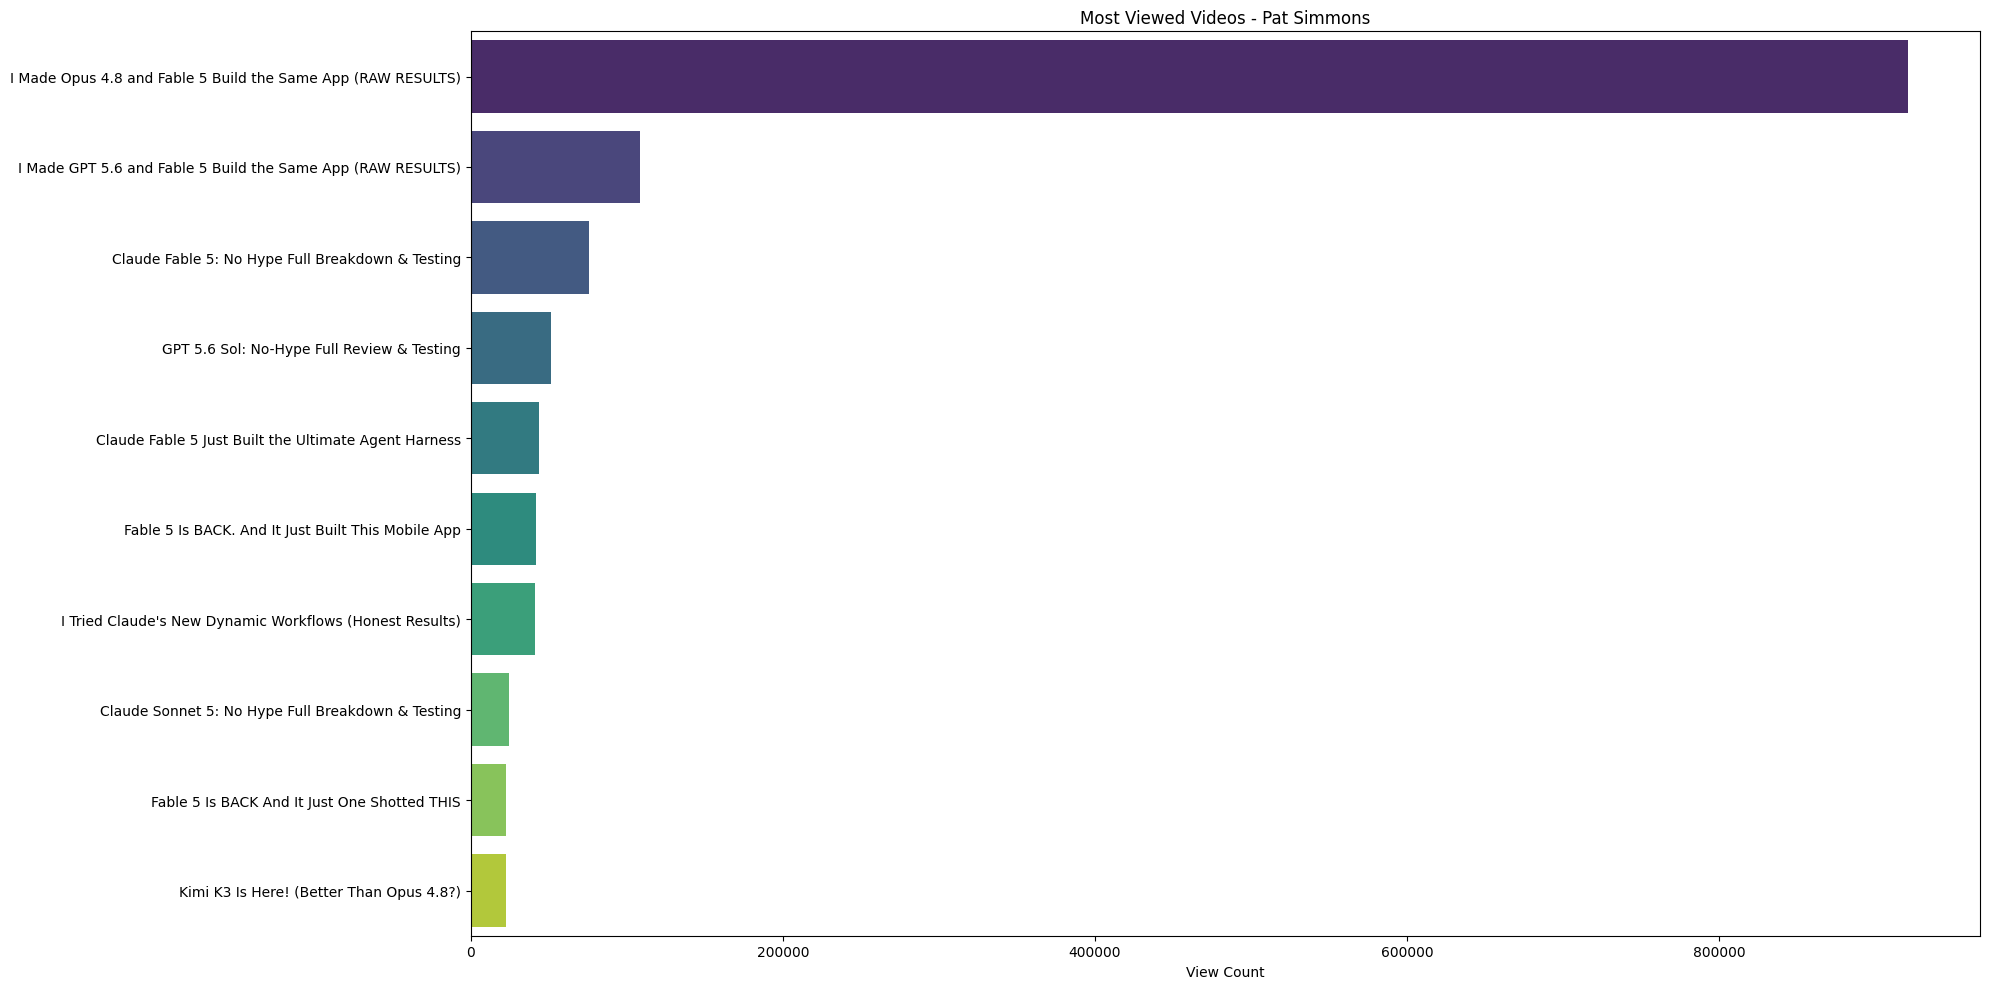

In [37]:
# Cell 15: Visualize Most Viewed Videos
plt.figure(figsize=(20, 10))
plot = sns.barplot(
    x="view_count", 
    y="title", 
    hue="title",  # Add this line
    data=df_highest_views,
    palette="viridis",
    legend=False  # Keep this to hide legend
)
plot.set(xlabel='View Count', ylabel='')
plot.set_title(f'Most Viewed Videos - {channel_stats[0]["snippet"]["title"]}')
plt.tight_layout()
plt.show()

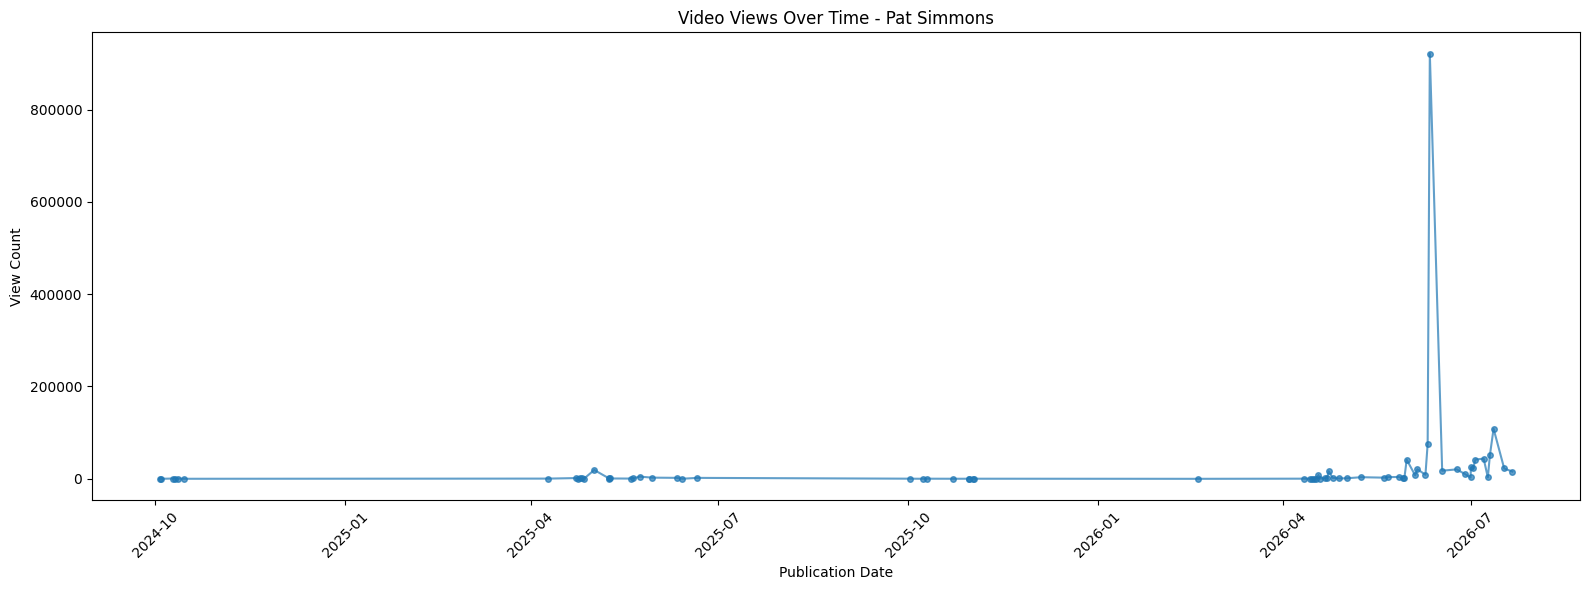

In [39]:
# Cell 16: Visualize Views Over Time
plt.figure(figsize=(16, 6))
plt.plot(df_sorted['published'], df_sorted['view_count'], 'o-', alpha=0.7, markersize=4)
plt.xlabel('Publication Date')
plt.ylabel('View Count')
plt.title(f'Video Views Over Time - {channel_stats[0]["snippet"]["title"]}')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [41]:
# Cell 17: Save to CSV
cols_to_save = ['video_id', 'title', 'published_date', 'view_count', 'hms_format']
output_csv = f"pat_simmons.csv"
df[cols_to_save].to_csv(output_csv, index=False)
print(f"✅ Saved {len(df)} videos to {output_csv}")

✅ Saved 70 videos to pat_simmons.csv


In [43]:
# Cell 18: Save Top Videos to Excel
try:
    import openpyxl
    # Create Excel directory if it doesn't exist
    excel_dir = os.path.join(os.path.dirname(os.getcwd()), "Excel")
    os.makedirs(excel_dir, exist_ok=True)
    xsl_file = os.path.join(excel_dir, "pat_simmons.xlsx")
    
    # Save top 10 videos to Excel
    df_highest_views_copy = df_highest_views.copy()
    df_highest_views_copy['read'] = 'N'
    df_highest_views_copy[cols_to_save + ['read']].to_excel(xsl_file, index=False)
    print(f"✅ Saved top videos to {xsl_file}")
except Exception as e:
    print(f"⚠️ Could not save Excel file: {e}")
    print(f"   Error: {str(e)}")

✅ Saved top videos to C:\Users\User\OneDrive\A4\Excel\pat_simmons.xlsx


In [45]:
# Cell 19: Summary Statistics
print("\n" + "="*60)
print("📊 CHANNEL SUMMARY")
print("="*60)
print(f"Channel Name: {channel_stats[0]['snippet']['title']}")
print(f"Total Videos: {len(df)}")
print(f"Total Views: {df['view_count'].sum():,}")
print(f"Average Views per Video: {df['view_count'].mean():,.0f}")
print(f"Median Views per Video: {df['view_count'].median():,.0f}")
print(f"Total Likes: {df['like_count'].sum():,}")
print(f"Total Comments: {df['comment_count'].sum():,}")
print(f"Most Viewed Video: {df.loc[df['view_count'].idxmax(), 'title'][:60]}... ({df['view_count'].max():,} views)")
print(f"Least Viewed Video: {df.loc[df['view_count'].idxmin(), 'title'][:60]}... ({df['view_count'].min():,} views)")


📊 CHANNEL SUMMARY
Channel Name: Pat Simmons
Total Videos: 70
Total Views: 1,551,421
Average Views per Video: 22,163
Median Views per Video: 1,258
Total Likes: 33,324
Total Comments: 3,398
Most Viewed Video: I Made Opus 4.8 and Fable 5 Build the Same App (RAW RESULTS)... (921,178 views)
Least Viewed Video: Pat Simmons Live Stream... (0 views)


In [47]:
# Cell 20: Video Length Statistics
print("\n" + "="*60)
print("⏱️ VIDEO LENGTH STATISTICS")
print("="*60)
df['duration_minutes'] = df['duration_seconds'] / 60
print(f"Average Duration: {df['duration_minutes'].mean():.1f} minutes")
print(f"Median Duration: {df['duration_minutes'].median():.1f} minutes")
print(f"Shortest Video: {df['duration_minutes'].min():.1f} minutes")
print(f"Longest Video: {df['duration_minutes'].max():.1f} minutes")


⏱️ VIDEO LENGTH STATISTICS
Average Duration: 13.8 minutes
Median Duration: 11.4 minutes
Shortest Video: 0.0 minutes
Longest Video: 49.5 minutes


In [49]:
# Cell 21: Engagement Metrics
print("\n" + "="*60)
print("💬 ENGAGEMENT METRICS")
print("="*60)
df['like_rate'] = df['like_count'] / df['view_count'] * 100
df['comment_rate'] = df['comment_count'] / df['view_count'] * 100
print(f"Average Like Rate: {df['like_rate'].mean():.2f}%")
print(f"Average Comment Rate: {df['comment_rate'].mean():.2f}%")
print(f"Highest Like Rate: {df['like_rate'].max():.2f}%")
print(f"Highest Like Rate Video: {df.loc[df['like_rate'].idxmax(), 'title'][:60]}...")
print(f"Highest Comment Rate: {df['comment_rate'].max():.2f}%")
print(f"Highest Comment Rate Video: {df.loc[df['comment_rate'].idxmax(), 'title'][:60]}...")


💬 ENGAGEMENT METRICS
Average Like Rate: 2.11%
Average Comment Rate: 0.21%
Highest Like Rate: 5.70%
Highest Like Rate Video: I Was Wasting Hours on Thumbnails…So I Built This...
Highest Comment Rate: 1.33%
Highest Comment Rate Video: This ChatGPT Trick Fixed My Broken AI Voice Agents in 3 Minu...


### If want to search specific title

In [51]:
# Cell 22: Find "Claude Design Is ABSURD" - Final Check
print("\n" + "="*60)
print("🔍 SPECIFIC VIDEO SEARCH")
print("="*60)

# Search for the exact video
exact_video = df[df['title'] == "Claude Design Is ABSURD"]
if not exact_video.empty:
    print("✅ Found 'Claude Design Is ABSURD':")
    display(exact_video[['video_id', 'title', 'published_date', 'view_count', 'like_count', 'comment_count']])
else:
    print("❌ 'Claude Design Is ABSURD' not found in the dataset.")
    print("\nSearching for videos with 'Claude' in the title:")
    claude_videos = df[df['title'].str.contains("Claude", case=False, na=False)]
    if not claude_videos.empty:
        print(f"Found {len(claude_videos)} videos with 'Claude' in the title:")
        display(claude_videos[cols_to_display].head(10))
    else:
        print("No videos with 'Claude' in the title.")


🔍 SPECIFIC VIDEO SEARCH
✅ Found 'Claude Design Is ABSURD':


,video_id,title,published_date,view_count,like_count,comment_count
32,SzUi_PJwnKY,Claude Design Is ABSURD,2026-04-18,8166,78,9



📊 VIDEO DISTRIBUTION BY LENGTH
length_category
Short (<5 min)         23
Medium (5-15 min)      20
Long (15-30 min)       19
Very Long (>30 min)     8
Name: count, dtype: int64


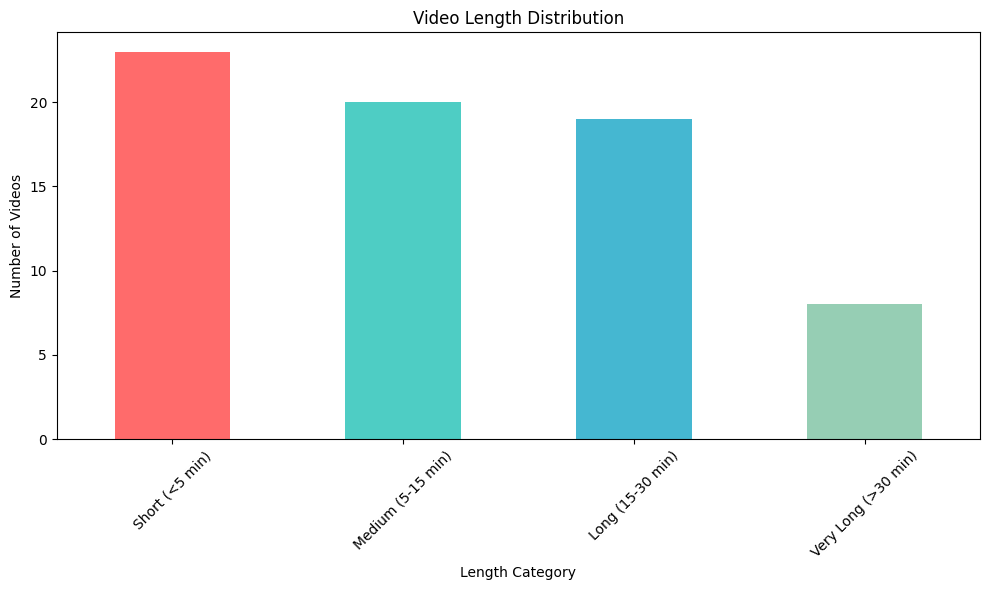

In [56]:
# Cell 23: Additional Analysis - Video Distribution by Length
print("\n" + "="*60)
print("📊 VIDEO DISTRIBUTION BY LENGTH")
print("="*60)

# Categorize videos by length
def categorize_video(minutes):
    if minutes < 5:
        return "Short (<5 min)"
    elif minutes < 15:
        return "Medium (5-15 min)"
    elif minutes < 30:
        return "Long (15-30 min)"
    else:
        return "Very Long (>30 min)"

df['length_category'] = df['duration_minutes'].apply(categorize_video)
length_distribution = df['length_category'].value_counts()
print(length_distribution)

# Visualize length distribution
plt.figure(figsize=(10, 6))
length_distribution.plot(kind='bar', color=['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4'])
plt.title('Video Length Distribution')
plt.xlabel('Length Category')
plt.ylabel('Number of Videos')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


📅 UPLOAD FREQUENCY BY MONTH
year_month
2024-10     6
2025-04     6
2025-05     8
2025-06     3
2025-10     6
2025-11     2
2026-02     1
2026-04    12
2026-05     8
2026-06     9
2026-07     9
Name: count, dtype: int64


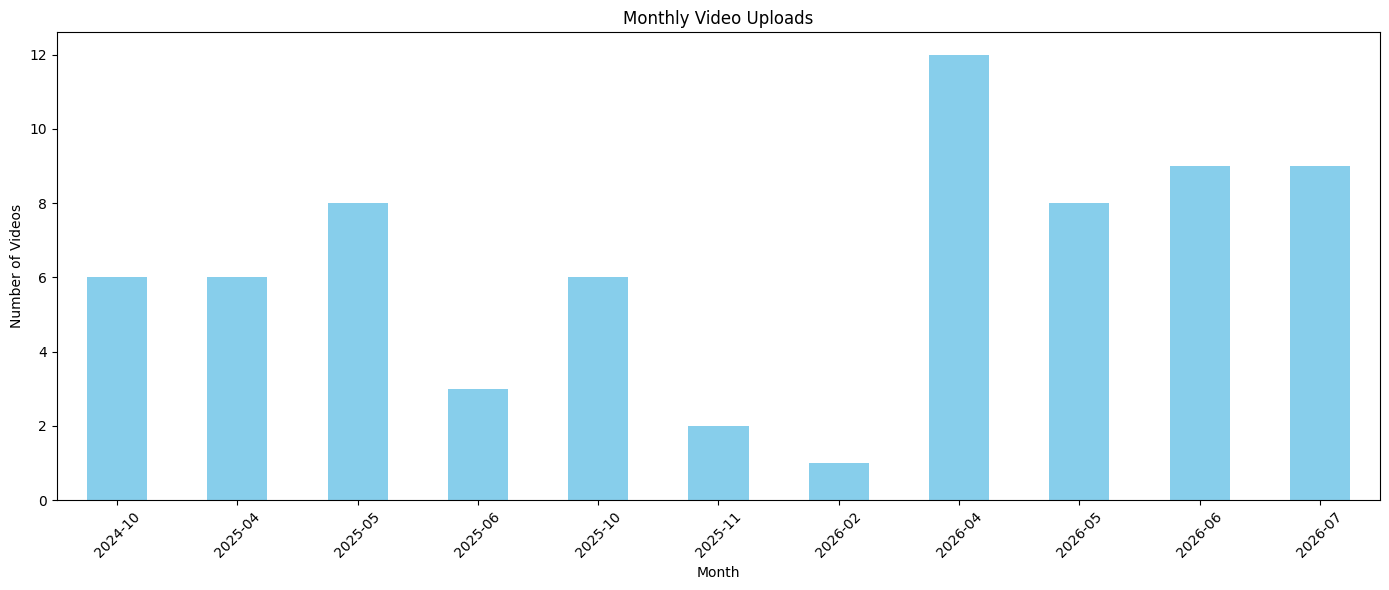


✅ Analysis Complete! All data has been processed and saved.


In [47]:
# Cell 24: Monthly Upload Frequency
print("\n" + "="*60)
print("📅 UPLOAD FREQUENCY BY MONTH")
print("="*60)

df['year_month'] = df['published'].dt.strftime('%Y-%m')
monthly_uploads = df['year_month'].value_counts().sort_index()
print(monthly_uploads.tail(12))  # Show last 12 months

# Visualize upload frequency
plt.figure(figsize=(14, 6))
monthly_uploads.plot(kind='bar', color='skyblue')
plt.title('Monthly Video Uploads')
plt.xlabel('Month')
plt.ylabel('Number of Videos')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print("\n✅ Analysis Complete! All data has been processed and saved.")